### Replacing Fourier Bank using a FNO-type layer

For Webster's equation.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt
from time import time

k_set = [ 10.0, 20.0, 30.0, 35.0, 40.0, 42.0, 44.0, 46.0, 48.0, 50.0 ]
Nf = 2500
adam_epochs = 2000
div0_threshold = 1e-6

torch.set_default_dtype ( torch.float64 )
device = torch.device ( "cuda" if torch.cuda.is_available() else "cpu" )
print ( "Active Hardware Target:", device )

class LatentFNOLayer ( nn.Module ):
    def __init__ ( self, latent_dim = 130, modes = 4 ):
        super().__init__()
        self.latent_dim = latent_dim
        self.modes = modes
        
        self.expansion = nn.Linear ( 1, latent_dim )
        
        scale = 1.0 / ( latent_dim * modes )
        self.complex_weights = nn.Parameter (
            scale * torch.randn ( 1, modes, dtype = torch.cdouble )
        )
        
    def forward ( self, x ):        
        h = self.expansion ( x )
        h = F.gelu ( h ) 
        
        h_ft = torch.fft.rfft ( h, dim = -1 )
        
        out_ft = torch.zeros_like ( h_ft )
        out_ft[:, :self.modes] = h_ft[:, :self.modes] * self.complex_weights
        
        h_out = torch.fft.irfft ( out_ft, n = self.latent_dim, dim = -1 )
        
        return h_out

class Helmholtz_PINN ( nn.Module ):
    def __init__ ( self, n_bank = 65, n_hidden = 7 ):
        super().__init__()

        self.n_bank = n_bank
        self.n_hidden = n_hidden
        
        latent_dim = 2 * n_bank
        
        self.fno_input = LatentFNOLayer ( latent_dim = latent_dim, modes = 4 )
        
        self.layers = nn.ModuleList()

        for i in range ( n_hidden ):
            self.layers.append ( nn.Linear ( latent_dim, latent_dim ) )

        self.layers.append ( nn.Linear ( latent_dim, 1 ) )
        
        self.apply ( self.init_weights )

    def init_weights ( self, m ):
        if isinstance ( m, nn.Linear ):
            torch.nn.init.xavier_uniform_ ( m.weight )
            if m.bias is not None:
                m.bias.data.fill_ ( 0.0 )

    def forward ( self, x ):
        out = self.fno_input ( x )
        
        for i in range ( self.n_hidden ):
            out = torch.sin ( self.layers[i](out) )
            
        network_out = self.layers[-1](out)

        boundary_line = 1.0 - 2.0 * x
        distance_func = x * ( 1.0 - x )
        
        p_hat = boundary_line + distance_func * network_out
        return p_hat

def net_loss ( model, x, k, return_pointwise = False ):
    p = model ( x )

    dp_dx = torch.autograd.grad (
        p, x,
        grad_outputs = torch.ones_like(p),
        create_graph = True,
        retain_graph = True
    )[0]

    d2p_dx2 = torch.autograd.grad (
        dp_dx, x,
        grad_outputs = torch.ones_like ( dp_dx ),
        create_graph = True,
        retain_graph = True
    )[0]

    h1, w1 = 0.010, 0.020 
    h2, w2 = 0.030, 0.060 
    x1, x2 = 0.0, 1.0

    mh = (h2 - h1) / (x2 - x1)
    mw = (w2 - w1) / (x2 - x1)

    S0 = 4.0 * h1 * w1
    S1 = 4.0 * (h1 * mw + w1 * mh)
    S2 = 4.0 * mh * mw

    S_x = S0 + S1 * x + S2 * (x ** 2)
    dS_dx = S1 + 2.0 * S2 * x

    residual = (d2p_dx2 / k) + (dS_dx / S_x) * (dp_dx / k) + (k * p)
    
    if return_pointwise:
        return torch.abs ( residual )

    return torch.mean ( residual ** 2 )

# Collocation points

x_f_base = torch.linspace ( 0, 1, Nf, device = device ).view ( -1, 1 )

models = []
loss_histories = []

model = Helmholtz_PINN ( n_bank = 16, n_hidden = 7 ).to ( device )

start = time()

for k in k_set:
    
    x_f = x_f_base.clone()
    x_f.requires_grad = True

    adam_opt = torch.optim.Adam ( model.parameters(), lr = 0.001, weight_decay = 1e-5 )

    loss_history = []

    print ( "INFO: Adam Training Started For k = {}".format ( k ) )    
    for epoch in range ( adam_epochs ):
        adam_opt.zero_grad()
        loss = net_loss ( model, x_f, k )
        loss.backward()
        adam_opt.step()
        
        loss_history.append ( loss.item() )
        
        if ( epoch + 1 ) % 200 == 0:
            with torch.no_grad():
                x_candidate = torch.linspace ( 0, 1, 5000, device = device ).view ( -1, 1 )
            x_candidate.requires_grad = True
            
            abs_residual = net_loss ( model, x_candidate, k, return_pointwise = True )
            
            _, top_indices = torch.topk ( abs_residual.flatten(), 50 )
            x_f = torch.cat ( [ x_f.detach(), x_candidate[top_indices].detach() ], dim = 0 )
            x_f.requires_grad = True
            print ( "INFO: k = {}; Iteration: {}; Loss: {}; Time: {}".format ( k, len ( loss_history ), loss.item(), time() - start ) )


    print ( "INFO: Adam Training Done For k = {}\n".format ( k ) )

    # Define LBFGS

    define_iters = 200 * k
    if ( k >= 50 ):
        define_iters += 5000

    opt = torch.optim.LBFGS (
        model.parameters(),
        lr = 1.0,
        max_iter = define_iters,
        line_search_fn = "strong_wolfe" )

    # Since LBFGS may need to call the objective functions multiple times in a single iteration, we need a closure function

    def closure():
        # Loss calculation
        opt.zero_grad()
        loss = net_loss ( model, x_f, k )
        loss.backward()
        
        loss_history.append ( loss.item() )
        if len ( loss_history ) % 1000 == 0:
            print ( "INFO: k = {}; Iteration: {}; Loss: {}; Time: {}".format ( k, len ( loss_history ), loss.item(), time() - start ) )
        return loss

    print ( "INFO: LBFGS Training Started For k = {}".format ( k ) )
    opt.step ( closure )
    print ( "INFO: LBFGS Training Done For k = {}\n".format ( k ) )
    
    models.append ( copy.deepcopy ( model ) )
    loss_histories.append ( loss_history )

Active Hardware Target: cuda
INFO: Adam Training Started For k = 10.0
INFO: k = 10.0; Iteration: 200; Loss: 2.446312976864276; Time: 3.077821969985962
INFO: k = 10.0; Iteration: 400; Loss: 1.7010911903477473; Time: 6.002979755401611
INFO: k = 10.0; Iteration: 600; Loss: 1.5099238589776411; Time: 9.15432333946228
INFO: k = 10.0; Iteration: 800; Loss: 1.2386583440507726; Time: 12.645769596099854
INFO: k = 10.0; Iteration: 1000; Loss: 1.1249873697248656; Time: 16.257700443267822
INFO: k = 10.0; Iteration: 1200; Loss: 0.9740435721305198; Time: 19.91103506088257
INFO: k = 10.0; Iteration: 1400; Loss: 0.96638935454854; Time: 23.581259965896606
INFO: k = 10.0; Iteration: 1600; Loss: 0.9548033943052343; Time: 27.28193497657776
INFO: k = 10.0; Iteration: 1800; Loss: 0.663981874459391; Time: 30.951370000839233
INFO: k = 10.0; Iteration: 2000; Loss: 0.5710811009485204; Time: 34.68113660812378
INFO: Adam Training Done For k = 10.0

INFO: LBFGS Training Started For k = 10.0
INFO: LBFGS Training Don

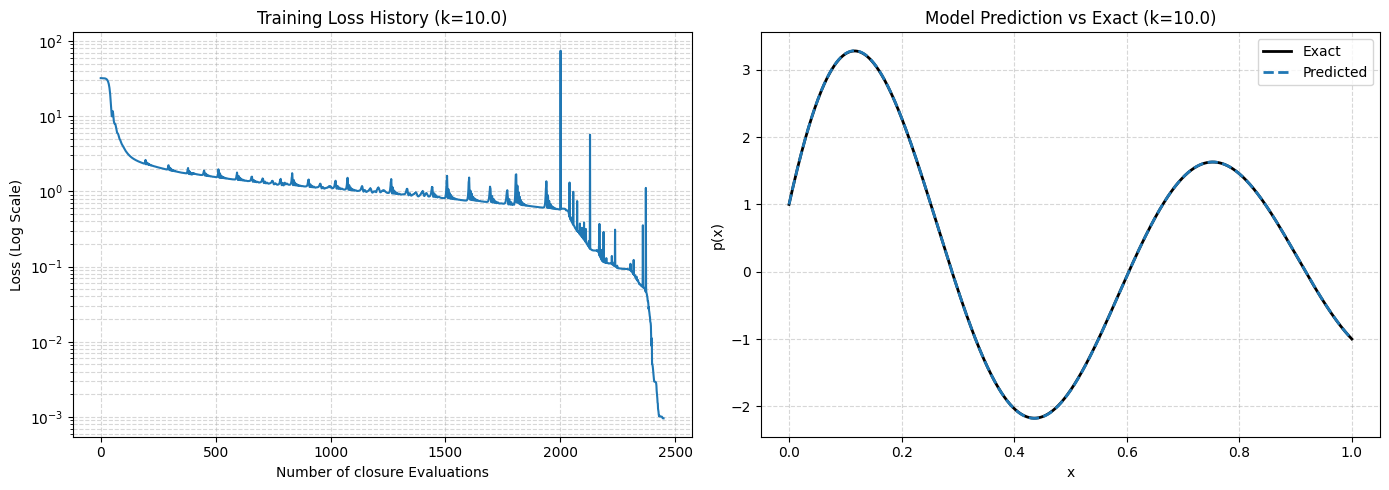

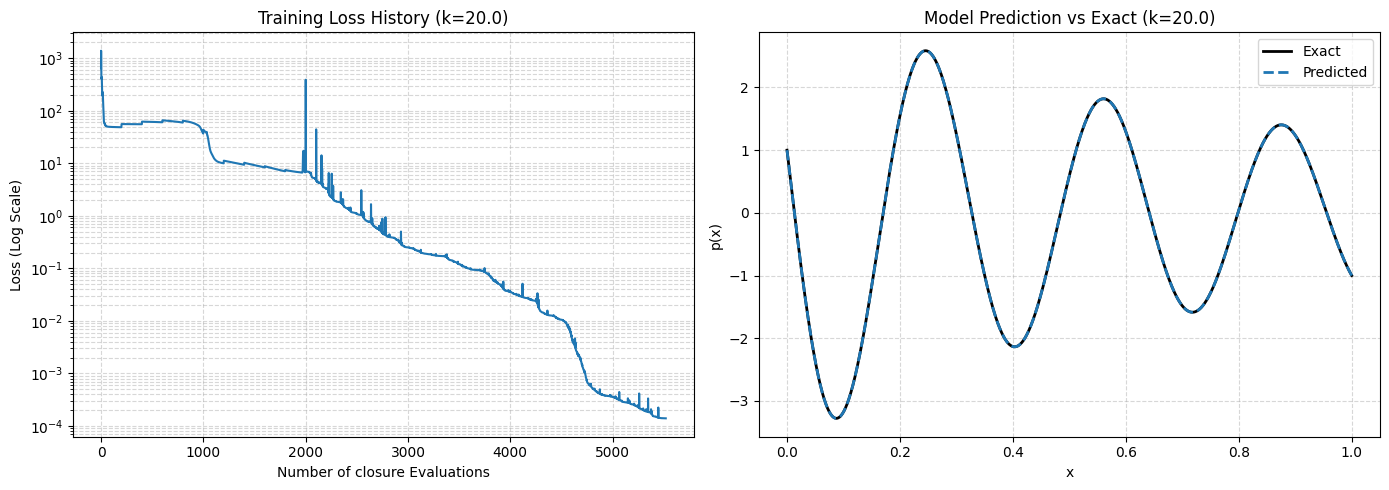

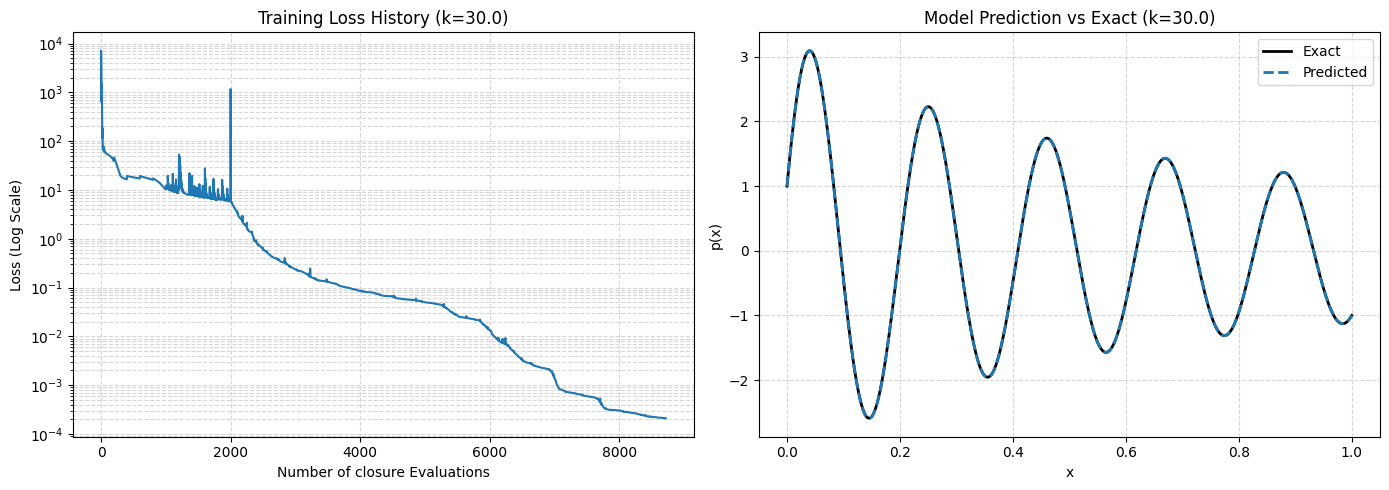

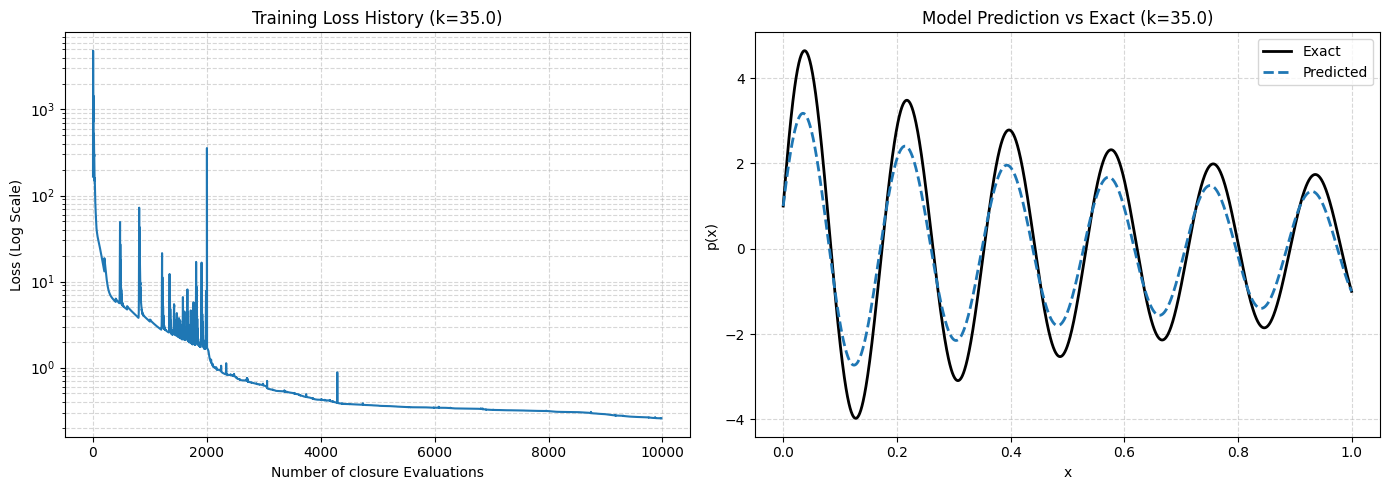

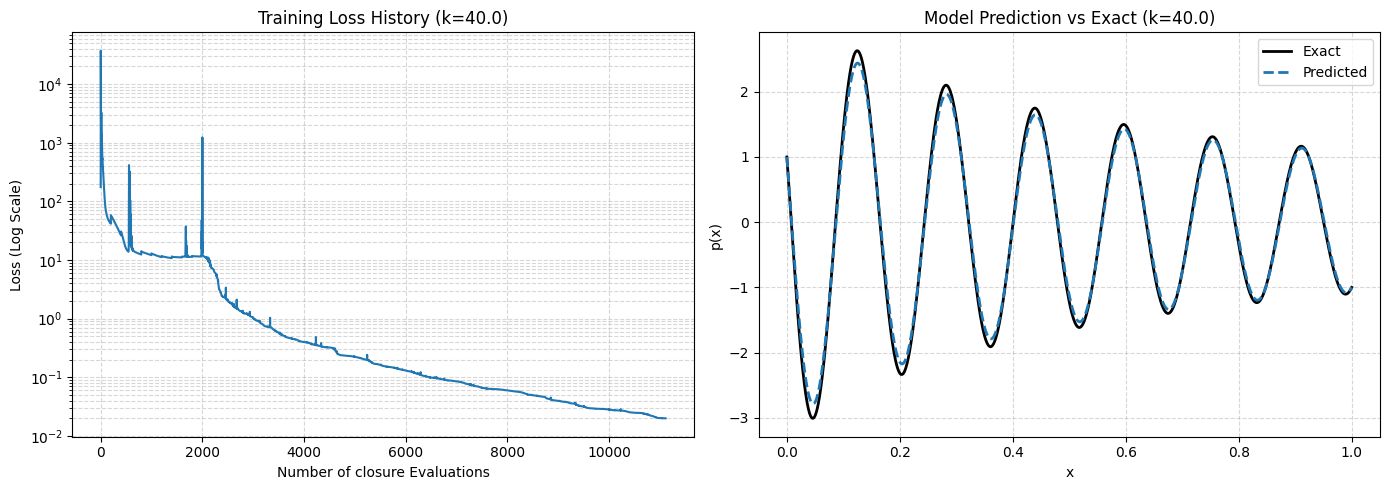

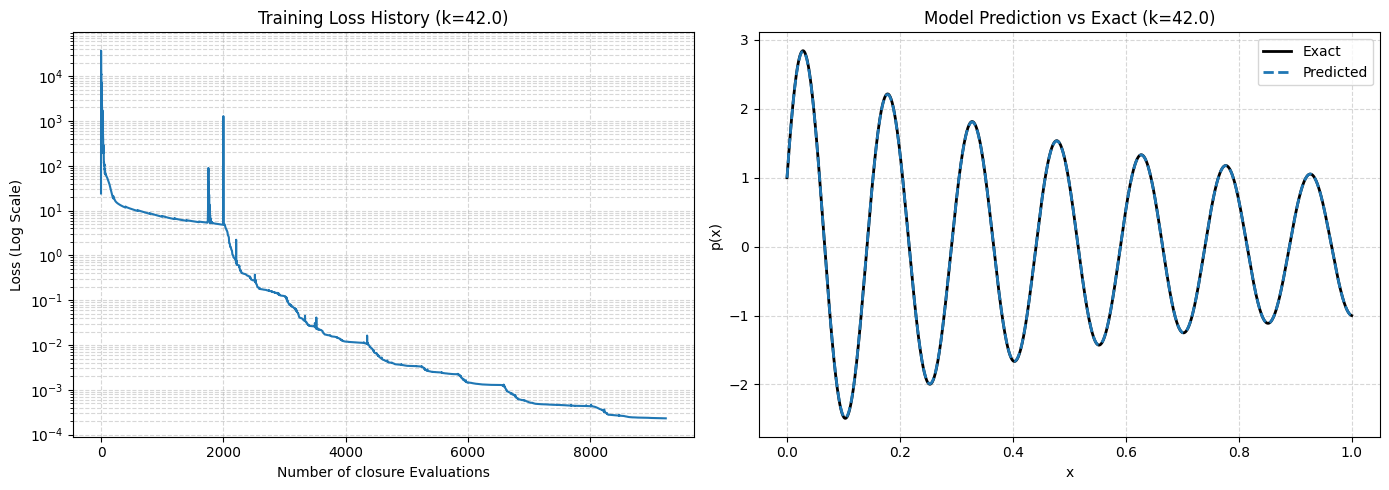

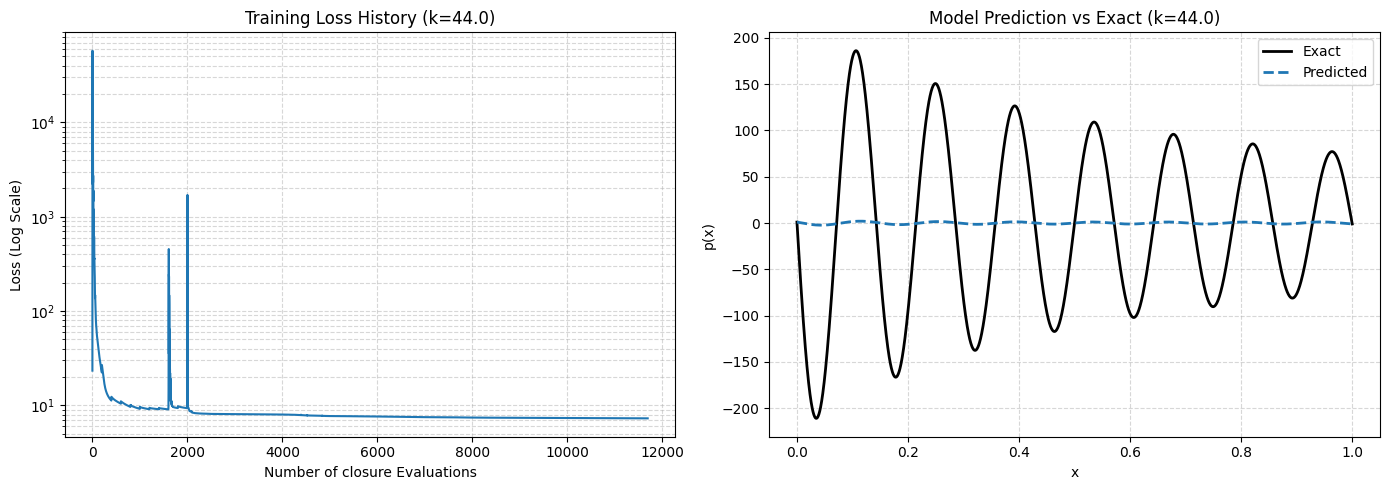

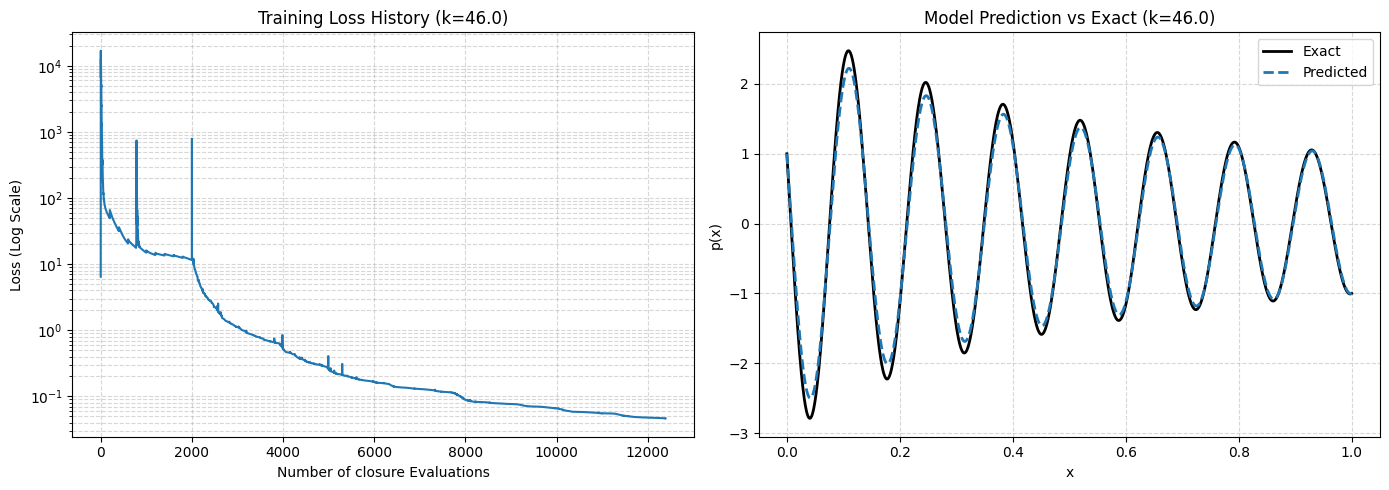

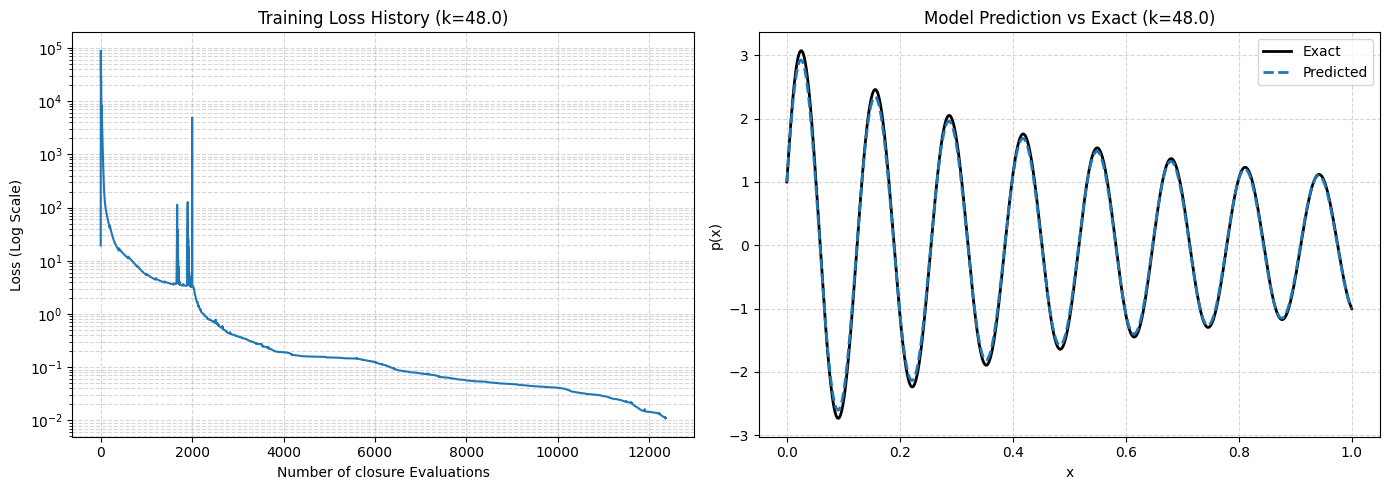

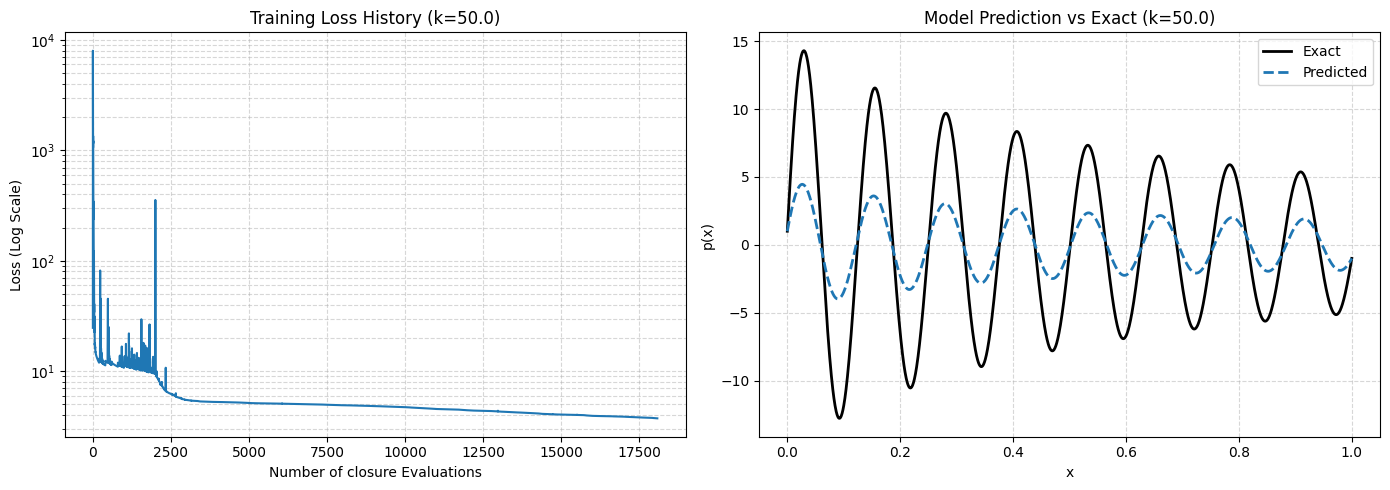

In [11]:
from scipy.integrate import solve_bvp

def exact_solution ( x, k ):
    h1, w1 = 0.010, 0.020 
    h2, w2 = 0.030, 0.060 
    x1_val, x2_val = 0.0, 1.0

    mh = ( h2 - h1 ) / ( x2_val - x1_val )
    mw = ( w2 - w1 ) / ( x2_val - x1_val )

    S0 = 4.0 * h1 * w1
    S1 = 4.0 * ( h1 * mw + w1 * mh )
    S2 = 4.0 * mh * mw

    def odefun ( x_val, y ):
        S = S0 + S1 * x_val + S2 * ( x_val ** 2 )
        dS = S1 + 2.0 * S2 * x_val
        return np.vstack ( ( y[1], - ( dS / S ) * y[1] - ( k ** 2 ) * y[0] ) )

    def bcfun ( ya, yb ):
        return np.array ( [ ya[0] - 1.0, yb[0] + 1.0 ] )

    x_init = np.linspace ( 0, 1, 500 )
    y_init = np.zeros ( ( 2, x_init.size ) )

    sol = solve_bvp ( odefun, bcfun, x_init, y_init )
    
    return sol.sol ( x )[0]

for i, k in enumerate ( k_set ):
    model = models[i]
    loss_history = loss_histories[i]

    with torch.no_grad():
        x_plot = torch.linspace ( 0, 1, 2000, device = device ).view ( -1, 1 )
        
        x_eval = x_plot.cpu().numpy().flatten()
        pred_eval = model ( x_plot ).cpu().numpy().flatten()
        exact_eval = exact_solution ( x_eval, k )

    fig, axs = plt.subplots ( 1, 2, figsize = (14, 5))

    # Plot loss history
    axs[0].plot ( loss_history )
    axs[0].set_yscale ( "log" )
    axs[0].set_xlabel ( "Number of closure Evaluations" )
    axs[0].set_ylabel ( "Loss (Log Scale)" )
    axs[0].set_title ( f"Training Loss History (k={k})" )
    axs[0].grid ( True, which = "both", linestyle="--", alpha = 0.5 )

    # Plot Exact vs Predicted
    axs[1].plot ( x_eval, exact_eval, 'k-', linewidth = 2, label = "Exact" )
    axs[1].plot ( x_eval, pred_eval, '--', linewidth = 2, label = "Predicted" )
    axs[1].set_xlabel ( "x" )
    axs[1].set_ylabel ( "p(x)" )
    axs[1].set_title ( f"Model Prediction vs Exact (k={k})" )
    axs[1].grid ( True, linestyle = "--", alpha = 0.5 )
    axs[1].legend()

    plt.tight_layout()
    plt.show()